# Object detection in PyTorch

Based on this course https://courses.cs.ut.ee/2026/DL4CV/spring/Main/Projects

Last week we have built a simple CNN-based classification model using PyTorch. We have experimented with creating our own dataset classes that are used in PyTorch to load and modify the data. Today, we will use this experience to repuprpose our simple CNN model from classification to object detection. We will do it by modifying the last fully-connected layer and adding an object detection head (YOLO style). To train and evaluate this new model will at first use an image of pugs that we will annotate manually, later we will switch to a larger dataset. Finally, we will see how the actual the performance of the actual YOLO model on the same data.

Let's get started by loading lots of PyTorch related libraries:

In [1]:
import torch
import torch.nn as nn # all the relevant building blocks
import torch.nn.functional as F # functional interfaces for many operations
from torch.utils.data import DataLoader # provides tools to work with data
import torch.optim as optim

Let's load our old friends as well as we will need them later to move numbers around in arrays as well as visualise data.

In [2]:
import numpy as np # for matrix stuff
import matplotlib.pyplot as plt # subjectively ugly plotting here

Here we are fixing all the sources of randomness to make sure that we all get the same models and the same results.

In [3]:
# All the different things we have to fix to make things reproducible
seed_value = 42

torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)  # if using multi-GPU
np.random.seed(seed_value)

# Optional: for further ensuring reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Now we can remind ourselves how our simple CNN model designed for classification looked like from the last practice session:

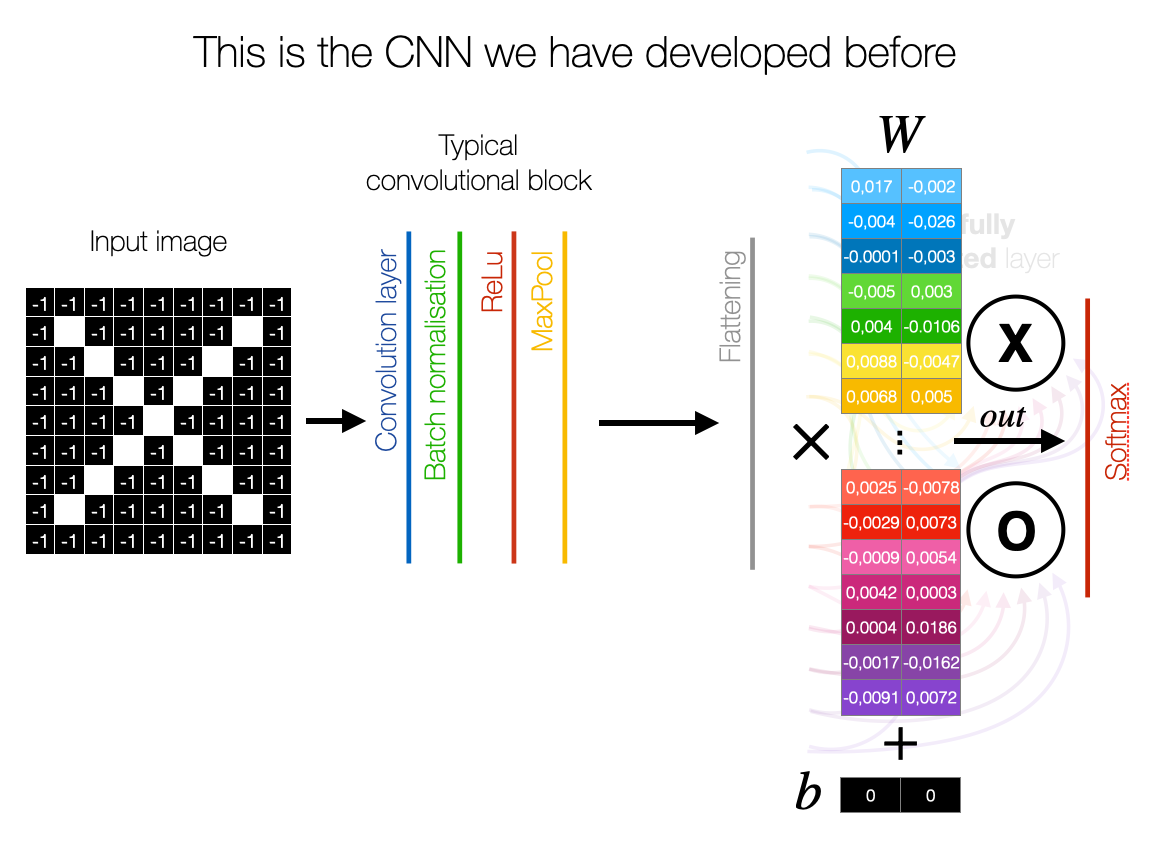

In this practice session we will modify it to predict YOLO style outputs for each object.

Here is the image I chose for us to work on. This is a nice one.

In [4]:
from pathlib import Path
from urllib.request import urlretrieve

pug_image_path = Path("pugs.jpg")
if not pug_image_path.exists():
    urlretrieve(
        "https://www.modernmolosser.com/wp-content/uploads/2015/10/Dollarphotoclub_11176252.jpg",
        pug_image_path,
    )

pug_image_path


PosixPath('pugs.jpg')

Let's read it in using `imread` function from `skimage.io`, this function call looks very clean and simple.

In [5]:
from skimage.io import imread # to load images from files
img = imread(pug_image_path)
img.shape


(2304, 3456, 3)

<font color=purple size=4>**Note**: There are other ways to read in images in Python, we have already seen one proposed by PIL library.
</font>

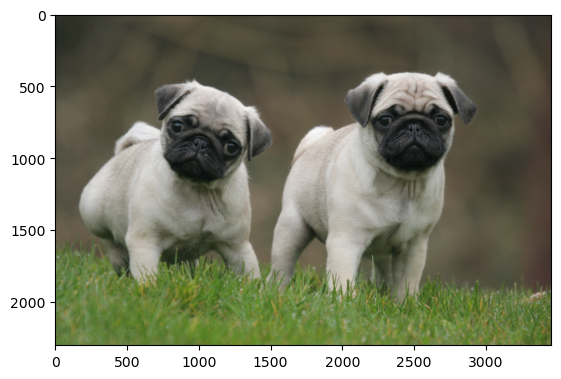

In [6]:
# and use matplotlib to visualise it
plt.imshow(img)

<font color=purple size=4>**Question**: What could be a problem with this image?
</font>

In [7]:
# to make my image slightly smaller
# I will resize it a bit (do not do it without a dire need)

# Desired length of the longest side
target_size = 416 # this is an arbitrary number, preferred by some models

# Calculate resize scale
scale = target_size / max(img.shape)

# Calculate new dimensions
img_width = int(img.shape[1] * scale)
img_height = int(img.shape[0] * scale)
print(f'New size should be {img_width}x{img_height}, after applying scale factor of {scale} to the original image')

New size should be 416x277, after applying scale factor of 0.12037037037037036 to the original image


Above we calculated the new image sizes, now in order to actually resize our image we will use `resize` function from `cv2` library (OpenCV). This function fits cubic spline to interpolate data inbetween our points. Look this [example](https://atozmath.com/example/CONM/CubicSpline.aspx?q1=E1) up to understand better the main principles of such interpolation.

In [8]:
import cv2
img = cv2.resize(img, dsize=(img_width, img_height), interpolation=cv2.INTER_CUBIC)

Now, we are ready to obtain more compact image that we will use for our model.

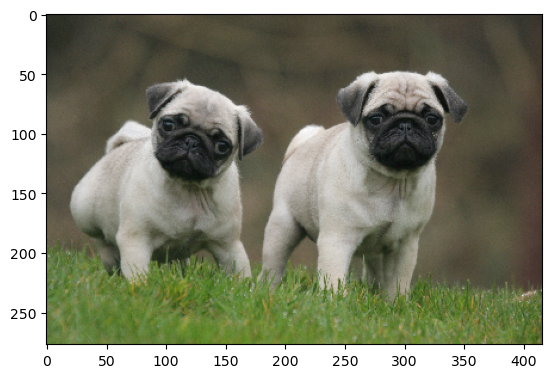

In [9]:
plt.imshow(img)

## Manually annotating image with bounding boxes
We have now loaded an image that we will be working with. It is cute, but there is a problem, both objects that we see on this image are localised only in our brain. CNN model that we are going to train need something more reliable to train against. One way to train our object detection model is provide it with bounding box coordinates. We will use `[center x, center y, width, height]` format to describe every object. Below we will try manually define bounding boxes for both objets.

But first, we will define a function that will help us to draw the resulting boxes.

In [10]:
# Function to draw rectangle given center, width, and height
def draw_rectangle(center_x, center_y, width, height, color = 'red'):
    top_left = (center_x - width // 2, center_y - height // 2)
    bottom_right = (center_x + width // 2, center_y + height // 2)

    # Plotting each edge of the rectangle
    plt.plot([top_left[0], top_left[0]], [top_left[1], bottom_right[1]], '-', color = color) # Left edge
    plt.plot([bottom_right[0], bottom_right[0]], [top_left[1], bottom_right[1]], '-', color = color) # Right edge
    plt.plot([top_left[0], bottom_right[0]], [top_left[1], top_left[1]], '-', color = color) # Top edge
    plt.plot([top_left[0], bottom_right[0]], [bottom_right[1], bottom_right[1]], '-', color = color) # Bottom edge

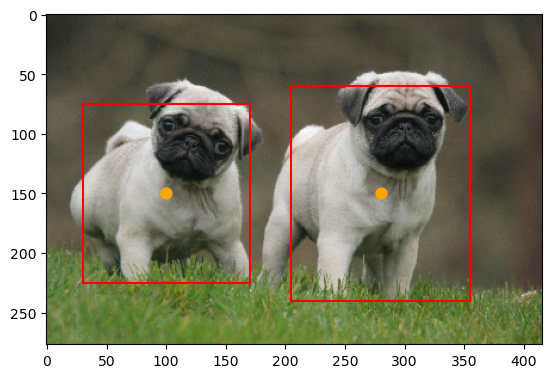

In [11]:
# Define the center, width, and height for rectangles
# Each tuple represents (center_x, center_y, width, height)
pugs = [
    #### YOUR CODE STARTS HERE ####
    (100, 150, 140, 150), # Pug 1
    (280, 150, 150, 180)  # Pug 2
    #### YOUR CODE ENDS HERE ####
]

# Create a plot
fig, ax = plt.subplots()
ax.imshow(img)

# Draw rectangles for each pug
for center_x, center_y, width, height in pugs:
    draw_rectangle(center_x, center_y, width, height)

    # adding centers to the image
    plt.scatter(center_x, center_y, color='orange', s = 60)

plt.show()

## Building small version of YOLOv1 for just one image
One of the most foundamental ideas behind YOLO (you only look once) architecture was dividing input image into grid cells. Here we will fix the grid size and visualise it on our sole image.

In [12]:
grid_height = 4
grid_width = 5

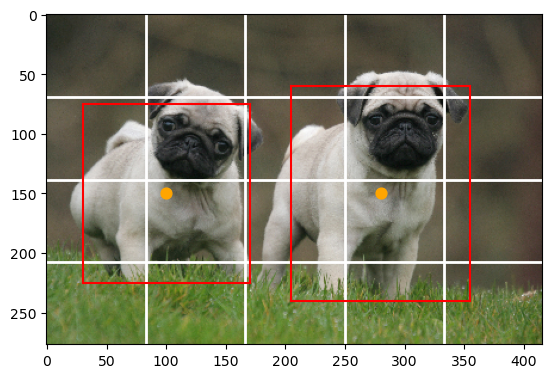

In [13]:
# Create a plot
fig, ax = plt.subplots()
ax.imshow(img)

# Draw a grid
# Draw all the vertical lines
for x in range(1, grid_width):
    plt.axvline(x=img_width/grid_width*x, color='white', linestyle='-', linewidth=2)

# Horizontal lines
for y in range(1, grid_height):
    plt.axhline(y=img_height/grid_height*y, color='white', linestyle='-', linewidth=2)


# Draw rectangles for each pug
for center_x, center_y, width, height in pugs:
    draw_rectangle(center_x, center_y, width, height)

    # adding centers to the image
    plt.scatter(center_x, center_y, color='orange', s = 60)

plt.show()

<font color=purple size=4>**Question**: What is important to note from this image?
</font>

At first, make sure that the force is with you...

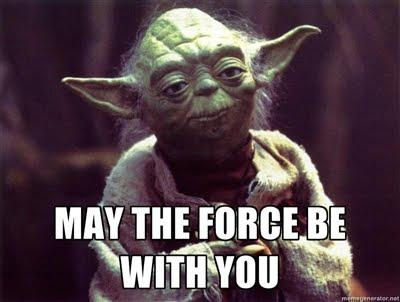

In [14]:
import torch

if torch.cuda.is_available():
    print("GPU is available")
    device = torch.device("cuda")
else:
    print("GPU is not available, using CPU instead")
    device = torch.device("cpu")

GPU is not available, using CPU instead


Now, we can build our YOLO-like object detection model in PyTorch. This model will have a 2d convolutional layer with `num_kernels` of size 3x3 and valid padding, ReLU activation, MaxPooling layer and a linear layer of the corresponding size. Below is the architecture of our model.

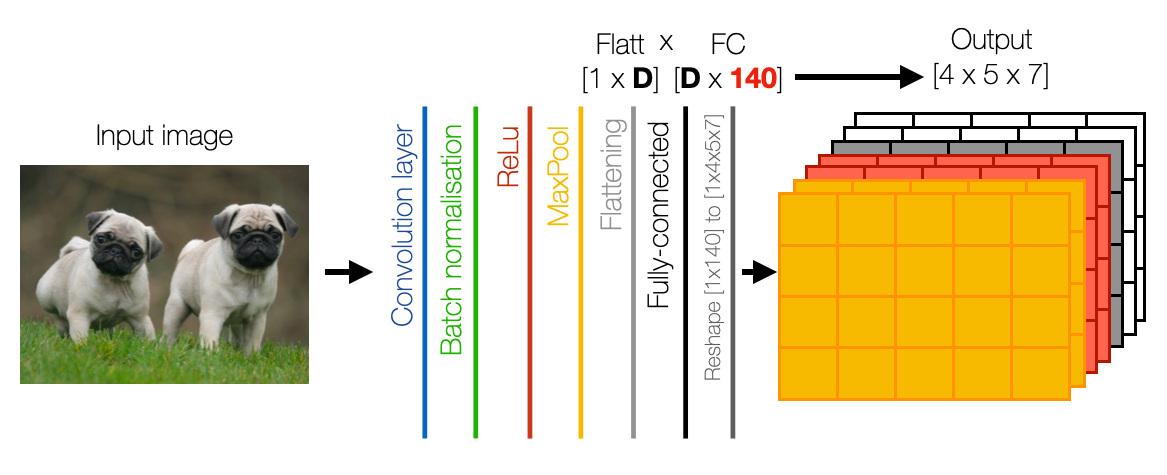

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, grid_height=4, grid_width=5, K=2, num_kernels=8, img_width = 416, img_height = 277):
        super(SimpleCNN, self).__init__()
        self.grid_height = grid_height
        self.grid_width = grid_width
        self.K = K


        self.conv1 = nn.Conv2d(3, num_kernels, kernel_size = 3, padding = 'valid')
        # self.batch = nn.BatchNorm2d(num_kernels) - there is no point in using batchnorm for one image
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size = 2, stride = 2)

        #### YOUR CODE STARTS HERE ####
        # What is the size of the feature map after the convolutional layer?
        # We use 3x3 kernel (K), no padding (P), stride of 1 (S)
        # (I - K - 2*P)/S + 1
        feature_map_h = img_height - 2
        feature_map_w = img_width - 2

        # What is the size of the feature map after the maxpooling layer?
        # Here we use 2x2 kernel, stride of 2, no padding and dialation of 1
        # Look up https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html
        D = ((feature_map_h - 1 - 1)//2 + 1) * ((feature_map_w - 1 - 1)//2 + 1) * num_kernels # size of the linear layer

        # We need to predict classes + center coordinates + sizes + confidence
        # for each grid cell
        # How many output values should our last fully connected layer produce?
        N = (4 + 1 + K) * self.grid_height * self.grid_width
        #### YOUR CODE ENDS HERE ####

        self.fc = nn.Linear(D, N)

    def forward(self, x):

        x = self.conv1(x) # convolutional layer
        # x = self.batch(x) # not using batch norm for just one image
        x = self.relu(x)
        x = self.maxpool(x)
        x = x.view(x.size(0), - 1) # Flatten the tensor before linear layer

        x = self.fc(x) # Linear layer

        #### YOUR CODE STARTS HERE ####
        # Reshape to [batch_size, grid_height, grid_width, K+4+1]
        x = x.view(-1, self.grid_height, self.grid_width, self.K+4+1)

        # Softmax if we had to use it would have been here:
        # x[..., 0:self.K] = torch.Softmax(x[..., 0:self.K]) # first K are responsible for K classes

        # Apply tanh to object center coordinates (assumed to be the next two values after class scores)
        x[..., self.K:self.K+2] = torch.tanh(x[..., self.K:self.K+2])

        # Apply sigmoid to width, height, and confidence (the next three values)
        x[..., self.K+2:self.K+5] = torch.sigmoid(x[..., self.K+2:self.K+5])
        #### YOUR CODE ENDS HERE ####
        return x

Now we are ready to initialise our model with all the hyperparameters fixed

In [16]:
# Initialize the model
K = 2 # number of classes (pugs vs loafs)
model = SimpleCNN(grid_height=4, grid_width=5, K=K, num_kernels=8, img_width = img_width, img_height = img_height)
model = model.to(device)
model.train()  # Set the model to training mode

# Choose an optimizer
optimizer = optim.Adam(model.parameters(), lr=0.00001)

Define the loss functions we will be using

In [17]:
#### YOUR CODE STARTS HERE ####
classification_loss = nn.CrossEntropyLoss() # For classes
bbox_loss = nn.MSELoss()  # We can also use SmoothL1Loss for bounding box coordinates and sizes
confidence_loss = nn.BCELoss()  # For object confidence scores
#### YOUR CODE ENDS HERE ####

Since we have multiple losses that are used on different parts of the outcome tensor we need a bit more code to compute the final loss.

In [18]:
def compute_loss(predictions, targets, lambda_coord=5, lambda_noobj=0.5, verbal = True):
    # Extract predictions
    pred_classes = predictions[..., :K]  # Assuming class scores are the first K channels
    pred_coords = predictions[..., K:K+2]  # Next two channels for coordinates
    pred_sizes = predictions[..., K+2:K+4]  # Sizes (width and height)
    pred_confidence = predictions[..., K+4]  # Confidence scores

    # Similar extraction needs to be done for targets based on our dataset structure
    # Extract targets
    targets_classes = targets[..., :K]
    targets_coords = targets[..., K:K+2]
    targets_sizes = targets[..., K+2:K+4]  # Sizes (width and height)
    targets_confidence = targets[..., K+4]  # Confidence scores

    # Compute losses for each part

    loss_classes = classification_loss(pred_classes, targets_classes)
    loss_coords = bbox_loss(pred_coords, targets_coords)
    loss_sizes = bbox_loss(pred_sizes, targets_sizes)
    loss_confidence = confidence_loss(pred_confidence, targets_confidence)

    if verbal:
      print(f'Classes loss: {loss_classes}; Coordinates loss: {loss_coords}; Sizes loss: {loss_sizes}; Confidence loss: {loss_confidence}')

    # Combine losses
    total_loss = loss_coords + lambda_coord * loss_sizes + lambda_noobj * loss_confidence + loss_classes

    return total_loss


Final thing before we can train our model is to prepare the ground truth tensor. We will first initialise it with 0s and then populate with relevant information only those grid cells which contain our object centers.

<font color=purple size=4>**Note**: This is just a bunch of geometry to make sure that our objects are stored in the right way for the model to learn.
</font>


In [19]:
# Initialize target tensor with zeros
targets = torch.zeros((grid_height, grid_width, K+4+1))

# Each tuple represents (center_x, center_y, width, height)
annotations = [
    (1, 100, 150, 165, 190), # Pug 1
    (1, 265, 145, 175, 200)  # Pug 2
]

cell_width = np.ceil(img_width / grid_width)
cell_height = np.ceil(img_height / grid_height)

# Populate targets based on annotations
for annotation in annotations:
    class_id, x_center, y_center, width, height = annotation

    # Determine which grid cell the center of the object falls into
    cell_x_id = int(x_center // cell_width)
    cell_y_id = int(y_center // cell_height)
    print(f'cell x id {cell_x_id}; cell y id {cell_y_id}')

    # Update class scores,
    targets[cell_y_id, cell_x_id, class_id] = 1  # Class score

    # Object center coordinates (scaled to -1 to 1)
    center_x = 2*(x_center - (cell_x_id + 1 - 0.5) * cell_width)/cell_width
    center_y = 2*(y_center - (cell_y_id + 1 - 0.5) * cell_height)/cell_height
    targets[cell_y_id, cell_x_id, 2:4] = torch.tensor([center_x, center_y])
    print(print(f'center x of the object {center_x}; center y of the object height {center_y} (inside the cell, from -1 to 1)'))

    # Object width, height, and confidence for the cell
    relative_width = width/img_width
    relative_height = height/img_height
    targets[cell_y_id, cell_x_id, 4:6] = torch.tensor([relative_width, relative_height])  # Width and height
    print(f"object's width {relative_width}; object's height {relative_height} (relative to the entire image)")

    # Confidence of objects in the ground truth is of course 100%
    targets[cell_y_id, cell_x_id, 6] = 1

cell x id 1; cell y id 2
center x of the object -0.6190476190476191; center y of the object height -0.7142857142857143 (inside the cell, from -1 to 1)
None
object's width 0.39663461538461536; object's height 0.6859205776173285 (relative to the entire image)
cell x id 3; cell y id 2
center x of the object -0.6904761904761905; center y of the object height -0.8571428571428571 (inside the cell, from -1 to 1)
None
object's width 0.4206730769230769; object's height 0.7220216606498195 (relative to the entire image)


In [20]:
targets.shape

torch.Size([4, 5, 7])

In [21]:
from torchvision import transforms

# We need to transform both the image and targets to PyTorch tensor
transform = transforms.ToTensor()
images = transform(img).unsqueeze(dim = 0)
targets = targets.unsqueeze(dim = 0)

num_epochs = 100
for epoch in range(num_epochs):
  images, targets = images.to(device), targets.to(device)
  optimizer.zero_grad()  # Zero the gradients

  # Forward pass
  outputs = model(images)

  # Compute loss
  loss = compute_loss(outputs, targets)

  # Backward pass and optimize
  loss.backward()
  optimizer.step()

  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}")


Classes loss: 0.27688032388687134; Coordinates loss: 0.051287077367305756; Sizes loss: 0.22908847033977509; Confidence loss: 0.6906722784042358
Epoch [1/100], Loss: 1.8189458847045898
Classes loss: 0.22373180091381073; Coordinates loss: 0.03803189843893051; Sizes loss: 0.1880686730146408; Confidence loss: 0.6021124124526978
Epoch [2/100], Loss: 1.50316321849823
Classes loss: 0.1768319308757782; Coordinates loss: 0.016594979912042618; Sizes loss: 0.15192633867263794; Confidence loss: 0.5223432779312134
Epoch [3/100], Loss: 1.2142302989959717
Classes loss: 0.13688790798187256; Coordinates loss: 0.008888226933777332; Sizes loss: 0.12100143730640411; Confidence loss: 0.4512544274330139
Epoch [4/100], Loss: 0.9764105081558228
Classes loss: 0.10413406044244766; Coordinates loss: 0.009001953527331352; Sizes loss: 0.09527640044689178; Confidence loss: 0.3885607421398163
Epoch [5/100], Loss: 0.7837983965873718
Classes loss: 0.07824288308620453; Coordinates loss: 0.006373841315507889; Sizes loss

<font color=purple size=4>**Question**: Did our model learn well?
</font>

Let's find out!

In [22]:
model.eval()  # Set the model to evaluation mode
test_images = images # use the same image as a test image (lame, yeah, I know)

with torch.inference_mode(): # disable gradient calculation
    test_images = test_images.to(device)

    # only feedforward pass
    outputs = model(test_images)

    # For each grid cell predict class
    predicted_classes = torch.argmax(outputs[...,:K], dim = -1).detach().cpu().numpy()

    # For each grid cell predict x and y
    predicted_centers_x = torch.round(outputs[...,K], decimals = 3).detach().cpu().numpy()
    predicted_centers_y = torch.round(outputs[...,K+1], decimals = 3).detach().cpu().numpy()

    # For each grid cell predict width and height of the object
    predicted_widths = torch.round(outputs[...,K+2], decimals = 3).detach().cpu().numpy()
    predicted_heights = torch.round(outputs[...,K+3], decimals = 3).detach().cpu().numpy()
    predicted_confidences = torch.round(outputs[...,K+4], decimals = 3).detach().cpu().numpy()


In [23]:
predicted_confidences

array([[[0.005, 0.005, 0.004, 0.005, 0.005],
        [0.006, 0.005, 0.005, 0.005, 0.005],
        [0.005, 0.995, 0.005, 0.996, 0.005],
        [0.004, 0.005, 0.005, 0.005, 0.005]]], dtype=float32)

Here we will take a look at the confident predictions (all the rest are nulified)

In [24]:
predicted_confidences
predicted_confidences[predicted_confidences > 0.8] = 1

In [25]:
predicted_classes[predicted_confidences != 1] = 0
print(predicted_classes)

predicted_centers_x[predicted_confidences != 1] = 0
print(predicted_centers_x)

predicted_centers_y[predicted_confidences != 1] = 0
print(predicted_centers_y)

predicted_widths[predicted_confidences != 1] = 0
print(predicted_widths)

predicted_heights[predicted_confidences != 1] = 0
print(predicted_heights)

[[[0 0 0 0 0]
  [0 0 0 0 0]
  [0 1 0 1 0]
  [0 0 0 0 0]]]
[[[ 0.     0.     0.     0.     0.   ]
  [ 0.     0.     0.     0.     0.   ]
  [ 0.    -0.616  0.    -0.693  0.   ]
  [ 0.     0.     0.     0.     0.   ]]]
[[[ 0.     0.     0.     0.     0.   ]
  [ 0.     0.     0.     0.     0.   ]
  [ 0.    -0.715  0.    -0.88   0.   ]
  [ 0.     0.     0.     0.     0.   ]]]
[[[0.    0.    0.    0.    0.   ]
  [0.    0.    0.    0.    0.   ]
  [0.    0.397 0.    0.421 0.   ]
  [0.    0.    0.    0.    0.   ]]]
[[[0.    0.    0.    0.    0.   ]
  [0.    0.    0.    0.    0.   ]
  [0.    0.685 0.    0.722 0.   ]
  [0.    0.    0.    0.    0.   ]]]


<font color=purple size=4>**Question**: Does this look right?
</font>

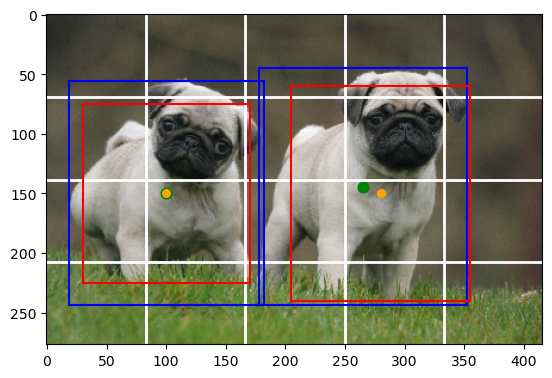

In [26]:
# Create a plot
fig, ax = plt.subplots()
ax.imshow(img)

# Draw a grid
# Draw all the vertical lines
for x in range(1, grid_width):
    plt.axvline(x=img_width/grid_width*x, color='white', linestyle='-', linewidth=2)

# Horizontal lines
for y in range(1, grid_height):
    plt.axhline(y=img_height/grid_height*y, color='white', linestyle='-', linewidth=2)

for grid_id_y, grid_id_x in np.stack(np.where(predicted_confidences[0] == 1), axis = -1):
  # Converting local x and y coordinates of the center of the object into global ones
  center_x = cell_width * grid_id_x + cell_width * (predicted_centers_x[0, grid_id_y, grid_id_x] + 1)/2
  center_y = cell_height * grid_id_y + cell_height * (predicted_centers_y[0, grid_id_y, grid_id_x] + 1)/2

  # Converting relative width and height into pixels
  width = predicted_widths[0, grid_id_y, grid_id_x] * img_width
  height = predicted_heights[0, grid_id_y, grid_id_x] * img_height

  # Draw the predicted rectangles
  draw_rectangle(center_x, center_y, width, height, 'blue')

  # Adding object centers to the image
  plt.scatter(center_x, center_y, color='green', s = 60)


# Draw rectangles for each ground truth
for center_x, center_y, width, height in pugs:
    draw_rectangle(center_x, center_y, width, height)

    # adding true centers to the image
    plt.scatter(center_x, center_y, color='orange', s = 30)

plt.show()

Well done! Aren't these results impressive? How about larger dataset?

# Training our object detection model on a larger dataset of fruits

We will now test our model's skills on the [Fruit Images for Object Detection](https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection) Dataset. This dataset contains labelled fruit images to train object detection systems. Three classes of fruits are labelled: apple, banana and orange. The rest of the fruits remain unlabelled (which is confusing for the model), also some apples, bananas and oranges are unlabelled as well (which is even more confusing).


# Local dataset setup

This notebook uses the Kaggle CLI from the Pixi environment instead of Colab uploads. Before running the download cell, authenticate once in a terminal with `pixi run kaggle auth login --no-launch-browser`, or set `KAGGLE_API_TOKEN` in your environment. The notebook will download and extract the fruit dataset into `fruits/` if it is not already present.


In [27]:
from pathlib import Path
import os
import subprocess
import zipfile

DATASET_SLUG = "mbkinaci/fruit-images-for-object-detection"
DATASET_ZIP = Path("fruit-images-for-object-detection.zip")
FRUITS_DIR = Path("fruits")
KAGGLE_CONFIG_DIR = Path.home() / ".kaggle"
KAGGLE_ACCESS_TOKEN = KAGGLE_CONFIG_DIR / "access_token"

# Keep Kaggle config in a predictable local directory and avoid Colab upload logic.
os.environ["KAGGLE_CONFIG_DIR"] = str(KAGGLE_CONFIG_DIR)

if not FRUITS_DIR.exists():
    if not DATASET_ZIP.exists():
        has_env_token = bool(os.environ.get("KAGGLE_API_TOKEN"))
        has_login_token = KAGGLE_ACCESS_TOKEN.exists()
        if not has_env_token and not has_login_token:
            raise FileNotFoundError(
                "Kaggle is not authenticated. Run `pixi run kaggle auth login --no-launch-browser` "
                "in a terminal, or set KAGGLE_API_TOKEN before starting Jupyter."
            )
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", DATASET_SLUG, "-p", "."],
            check=True,
            env=os.environ.copy(),
        )

    with zipfile.ZipFile(DATASET_ZIP) as archive:
        archive.extractall(FRUITS_DIR)

FRUITS_DIR


FileNotFoundError: Kaggle is not authenticated. Run `pixi run kaggle auth login --no-launch-browser` in a terminal, or set KAGGLE_API_TOKEN before starting Jupyter.

print("Fruit dataset directory:", FRUITS_DIR.resolve())
print("Top-level entries:", sorted(path.name for path in FRUITS_DIR.iterdir()))


In [ ]:
train_dir = FRUITS_DIR / "train_zip" / "train"
test_dir = FRUITS_DIR / "test_zip" / "test"

if not train_dir.exists() or not test_dir.exists():
    raise FileNotFoundError(
        f"Expected dataset folders were not found: {train_dir} and {test_dir}"
    )


Saving kaggle(1).json to kaggle(1).json


{'kaggle(1).json': b'{"username":"joonasariva","key":"9eeb9786c5e91fd7dec06c0f2685c968"}'}

In [ ]:
train_files = sorted(str(path) for path in train_dir.glob("*.jpg"))
test_files = sorted(str(path) for path in test_dir.glob("*.jpg"))

print(f"Train images: {len(train_files)}")
print(f"Test images: {len(test_files)}")


In [ ]:
print(train_files[:5])
print(test_files[:5])


ref                                                                 title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset              Screen Time, Sleep & Stress Analysis Dataset           787136  2026-02-13 06:56:18.757000          11050        222  1.0              
amar5693/student-performance-dataset                                Student Performance Dataset                            177286  2026-02-12 06:04:44.613000           9491        152  1.0              
shree0910/online-vs-in-store-shopping-behaviour-dataset             Online vs In-Store Shopping Behaviour Dataset          354896  2026-02-18 08:16:20.137000           1001         22  1.0

In [ ]:
example_annotation = train_dir / "orange_2.xml"
print(example_annotation.read_text().splitlines()[:50])


Dataset URL: https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection
License(s): CC0-1.0
  0% 0.00/28.4M [00:00<?, ?B/s]
100% 28.4M/28.4M [00:00<00:00, 1.58GB/s]


In [ ]:
# Dataset setup is complete. The remaining cells use train_files and test_files.


fruit-images-for-object-detection.zip  kaggle.json  pugs.jpg  sample_data


In [ ]:
# No Colab-specific extraction step is needed locally.


Now that the dataset is on drive, we can proceed to read in the file names.

In [ ]:
# train_files and test_files were created by the local dataset setup cells above.


In [ ]:
print(train_files[:5])
print(test_files[:5])

['fruits/train_zip/train/orange_69.jpg', 'fruits/train_zip/train/orange_49.jpg', 'fruits/train_zip/train/apple_3.jpg', 'fruits/train_zip/train/banana_5.jpg', 'fruits/train_zip/train/apple_7.jpg']
['fruits/test_zip/test/banana_82.jpg', 'fruits/test_zip/test/banana_81.jpg', 'fruits/test_zip/test/banana_93.jpg', 'fruits/test_zip/test/orange_85.jpg', 'fruits/test_zip/test/mixed_23.jpg']


Define `classes` that we will be trying to predict.

In [ ]:
classes = ['apple', 'banana', 'orange'] # we know it from Kaggle

<font color=purple size=4>**Question**: Before we can unleash our model on this dataset we will have to make a few adjustments. Can you guess which ones?
</font>

First we will need to load the ground truth data. In this dataset it comes in a form of XML files. Need to understand how these files are structured

In [ ]:
example_annotation = train_dir / "orange_2.xml"
print("\n".join(example_annotation.read_text().splitlines()[:50]))


<annotation>
	<folder>train</folder>
	<filename>orange_2.jpg</filename>
	<path>C:\tensorflow1\models\research\object_detection\images\train\orange_2.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>670</width>
		<height>584</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>orange</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>87</xmin>
			<ymin>137</ymin>
			<xmax>325</xmax>
			<ymax>415</ymax>
		</bndbox>
	</object>
	<object>
		<name>orange</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>347</xmin>
			<ymin>127</ymin>
			<xmax>603</xmax>
			<ymax>398</ymax>
		</bndbox>
	</object>
</annotation>


<font color=purple size=4>**Question**: Look at this output and try to interpret the values that you see.
</font>

To extract object information from XML annotation files and convert them to YOLO format, you can use the xml.etree.ElementTree module in Python, which is a standard module for parsing XML data.

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
import numpy as np

class FruitDataset(Dataset):

    # This class is almost a complete copy and paste from the last week's CustomDataset
    def __init__(self, file_names, img_width=416, img_height=277, grid_size=(4, 5), num_classes=2, classes=classes):
        self.grid_size = grid_size
        self.classes = classes
        self.num_classes = len(classes)
        self.img_width = img_width
        self.img_height = img_height
        self.cell_width = np.ceil(self.img_width / self.grid_size[1])
        self.cell_height = np.ceil(self.img_height / self.grid_size[0])

        # Filtering out non-RGB images and reading them in
        self.rgb_file_names = [file_name for file_name in file_names if self._is_rgb(file_name)]
        self.images = [Image.open(file_name) for file_name in self.rgb_file_names]

        # Corresponding label files
        self.label_files = [file_name.replace('.jpg', '.xml') for file_name in self.rgb_file_names]

        # Image transformation
        # Here we only do Resize to 416 x 277
        self.transform = transforms.Compose([
            transforms.Resize((self.img_height, self.img_width)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label_file = self.label_files[idx]
        image_width, image_height = image.size

        scale_x = self.img_width / image_width
        scale_y = self.img_height / image_height

        # Transforming the image
        image = self.transform(image)

        # Parsing the XML file to get bounding boxes
        bboxes = self.parse_annotation(label_file, self.classes, scale_x, scale_y)

        # Preparing target tensor
        targets = self.create_targets_tensor(bboxes, self.grid_size, self.num_classes)

        return image, targets

    # static method means that we do not pass self into the method
    # useful when there is no need to access the class instance
    @staticmethod
    def _is_rgb(image_path):
        with Image.open(image_path) as image:
            return image.mode == 'RGB'

    @staticmethod
    def parse_annotation(annotation_path, classes, scale_x, scale_y):
        tree = ET.parse(annotation_path)
        root = tree.getroot()
        bboxes = []

        for obj in root.iter('object'):
            class_id = classes.index(obj.find('name').text)

            bndbox = obj.find('bndbox')
            xmin = int(int(bndbox.find('xmin').text) * scale_x)
            ymin = int(int(bndbox.find('ymin').text) * scale_y)
            xmax = int(int(bndbox.find('xmax').text) * scale_x)
            ymax = int(int(bndbox.find('ymax').text) * scale_y)
            bboxes.append((class_id, (xmin+xmax)/2, (ymin+ymax)/2, xmax-xmin, ymax-ymin))
        return bboxes

    # Probably the most elaborate method of our class
    # It is responsible for turning bbox annotations into target tensors
    def create_targets_tensor(self, annotations, grid_size, num_classes):
        targets = torch.zeros((*grid_size, num_classes + 5))
        for annotation in annotations:
            class_id, x_center, y_center, width, height = annotation

            cell_x_id = int(x_center // self.cell_width)
            cell_y_id = int(y_center // self.cell_height)

            if targets[cell_y_id, cell_x_id,  num_classes+4] == 1:
              break # if there is already an object in the same grid

            targets[cell_y_id, cell_x_id, class_id] = 1  # Class score
            targets[cell_y_id, cell_x_id, num_classes:num_classes+2] = torch.tensor([
                2*(x_center - (cell_x_id + 1 - 0.5) * self.cell_width) / self.cell_width,
                2*(y_center - (cell_y_id + 1 - 0.5) * self.cell_height) / self.cell_height
            ])  # Normalized center coordinates

            targets[cell_y_id, cell_x_id,  num_classes+2:num_classes+4] = torch.tensor([
                width / self.img_width, height / self.img_height
            ])  # Normalized width and height


            targets[cell_y_id, cell_x_id,  num_classes+4] = 1  # Confidence


        return targets


In [ ]:
train_dataset = FruitDataset(file_names=train_files, classes = classes)
val_dataset = FruitDataset(file_names=test_files, classes = classes)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

Apple class
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0.]])
Banana class
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])
Orange class
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])
X centers
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.1071,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
Y centers
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.2429,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
Widths
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.689

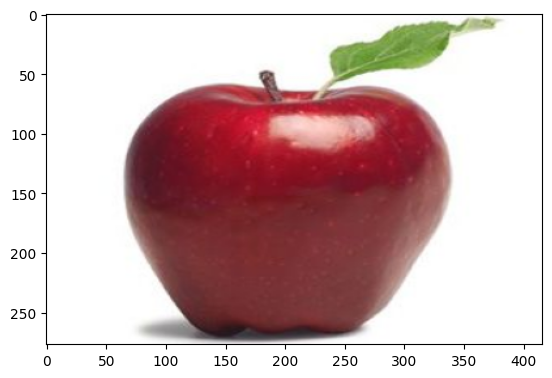

In [ ]:
for image_batch, targets_batch in train_loader:
  plt.imshow(image_batch[0].permute(1, 2, 0))
  print('Apple class')
  print(targets_batch[0][...,0]) # apple
  print('Banana class')
  print(targets_batch[0][...,1]) # banana
  print('Orange class')
  print(targets_batch[0][...,2]) # orange
  print('X centers')
  print(targets_batch[0][...,3])
  print('Y centers')
  print(targets_batch[0][...,4])
  print('Widths')
  print(targets_batch[0][...,5])
  print('Heights')
  print(targets_batch[0][...,6])
  print('Confidences')
  print(targets_batch[0][...,7])
  break

<font color=purple size=4>**Note**: This is important to understand the output of the previous cell to ensure that targets are assembeled correctly.
</font>

In [ ]:
def draw_rectangle(ax, center_x, center_y, width, height, color='red'):
    top_left = (center_x - width // 2, center_y - height // 2)
    bottom_right = (center_x + width // 2, center_y + height // 2)

    # Plotting each edge of the rectangle on the specified axes
    ax.plot([top_left[0], top_left[0]], [top_left[1], bottom_right[1]], '-', color=color)  # Left edge
    ax.plot([bottom_right[0], bottom_right[0]], [top_left[1], bottom_right[1]], '-', color=color)  # Right edge
    ax.plot([top_left[0], bottom_right[0]], [top_left[1], top_left[1]], '-', color=color)  # Top edge
    ax.plot([top_left[0], bottom_right[0]], [bottom_right[1], bottom_right[1]], '-', color=color)  # Bottom edge

def visualize_with_targets(ax, img, targets, num_classes, threshold = 0.5):
    """
    Visualize an image with bounding boxes on a given matplotlib axis.
    """
    # Convert tensor to numpy array for visualization, if necessary
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()  # Convert from [C, H, W] to [H, W, C]

    ax.imshow(img)
    ax.axis('off')  # Hide axis

    if isinstance(targets, torch.Tensor):
        grid_height, grid_width = targets.size()[:2]
    else:
        grid_height, grid_width = targets.shape[:2]
    img_height, img_width = img.shape[:2]
    cell_width = img_width / grid_width
    cell_height = img_height / grid_height

    # Draw grid lines
    for x in range(1, grid_width):
        ax.axvline(x=cell_width * x, color='white', linestyle='-', linewidth=1)
    for y in range(1, grid_height):
        ax.axhline(y=cell_height * y, color='white', linestyle='-', linewidth=1)

    # Iterate over grid cells to draw bounding boxes
    for grid_id_y, grid_id_x in np.stack(np.where(targets[...,num_classes+4] >= threshold), axis = -1):
      centers_x = targets[...,num_classes]
      centers_y = targets[...,num_classes+1]
      widths = targets[...,num_classes+2]
      heights = targets[...,num_classes+3]
      center_x = cell_width * grid_id_x + cell_width * (centers_x[grid_id_y, grid_id_x] + 1)/2
      center_y = cell_height * grid_id_y + cell_height * (centers_y[grid_id_y, grid_id_x] + 1)/2
      width = widths[grid_id_y, grid_id_x] * img_width
      height = heights[grid_id_y, grid_id_x] * img_height

      colours = ['red', 'yellow', 'orange']
      class_id = torch.argmax(targets[grid_id_y, grid_id_x, :num_classes])
      if heights[grid_id_y, grid_id_x] > 0.1 and widths[grid_id_y, grid_id_x] > 0.1:
          draw_rectangle(ax, center_x, center_y, width, height, colours[class_id])

          # adding centers to the image
          ax.scatter(center_x, center_y, color='red', s = 60)

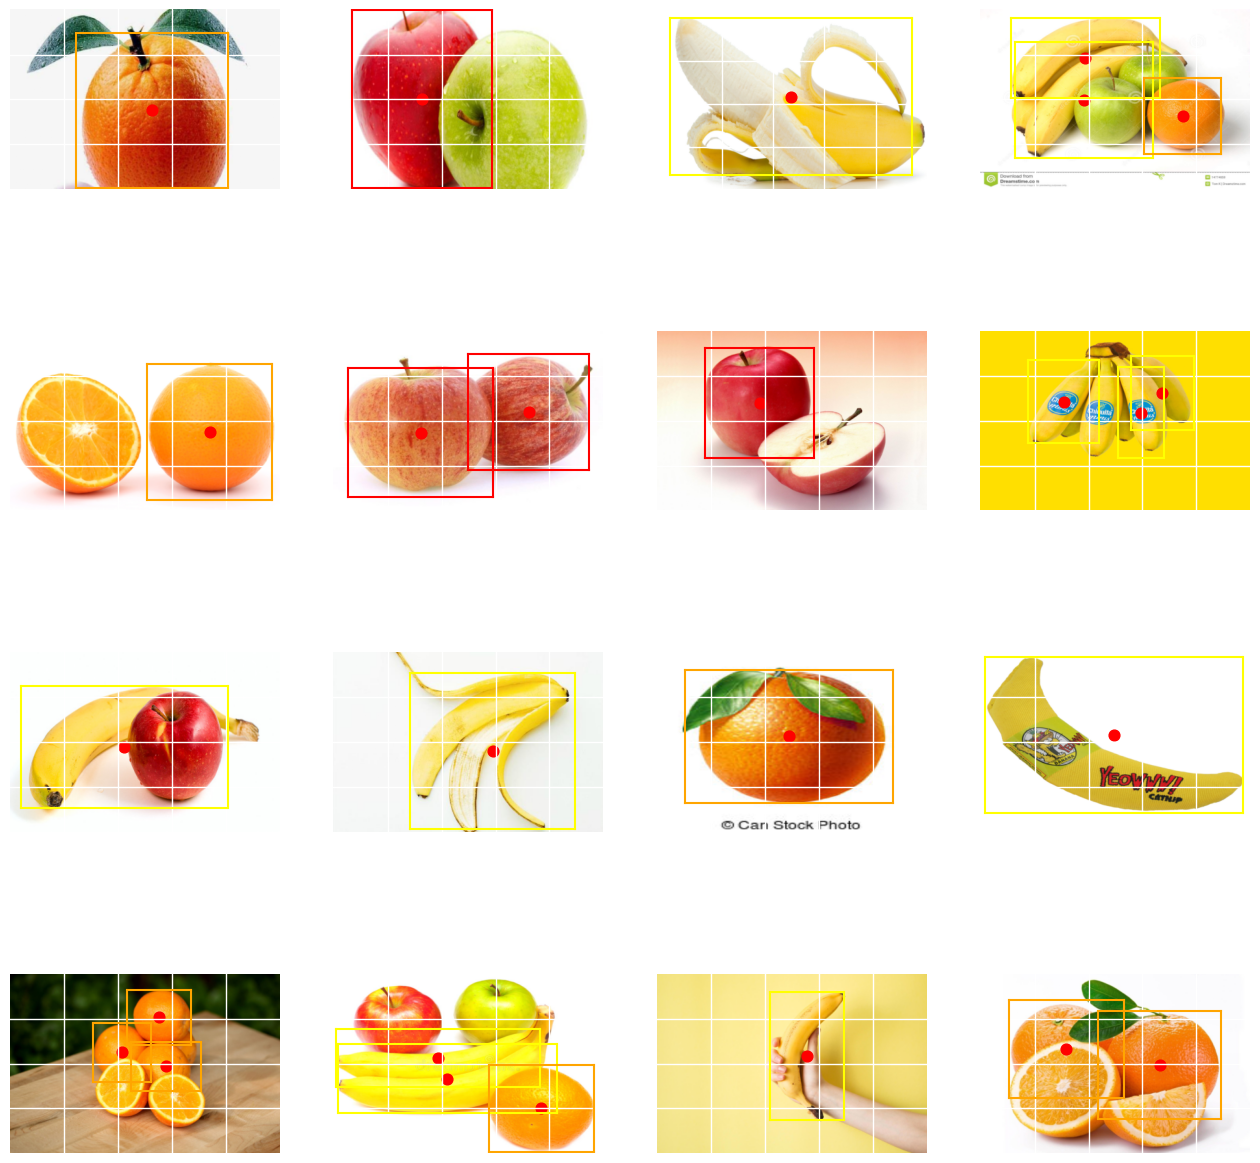

In [ ]:
import matplotlib.pyplot as plt

for image_batch, targets_batch in train_loader:
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()

    for i in range(16):
        ax = axes[i]
        img = image_batch[i]  # Current image tensor
        targets = targets_batch[i]  # Corresponding targets tensor

        # Assuming num_classes is known, adjust as necessary
        num_classes = len(classes)  # Example: change this to your actual number of classes

        # Call the visualization function for the current subplot axis
        visualize_with_targets(ax, img, targets, num_classes)

    plt.show()
    break  # Remove break to process more batches


<font color=purple size=4>**Question**: What can you say about these annotations?
</font>

In [ ]:
# Initialize the model
model = SimpleCNN(grid_height=4, grid_width=5, K=len(classes), num_kernels=8, img_width = img_width, img_height = img_height)
model = model.to(device)
model.train()  # Set the model to training mode

# Choose an optimizer
# 0.00001
optimizer = optim.Adam(model.parameters(), lr=0.00001)

# Initialise DataLoader right away
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [ ]:
num_epochs = 100
for epoch in range(num_epochs):
  for images, targets in train_loader:
    images, targets = images.to(device), targets.to(device)
    optimizer.zero_grad()  # Zero the gradients

    # Forward pass
    outputs = model(images)

    # Compute loss
    loss = compute_loss(outputs, targets, lambda_coord=5, lambda_noobj=0.5, verbal = True)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}")


Classes loss: 0.2087339609861374; Coordinates loss: 0.0615675263106823; Sizes loss: 0.13777843117713928; Confidence loss: 0.6893143653869629
Classes loss: 0.1199004203081131; Coordinates loss: 0.08052151650190353; Sizes loss: 0.1250060796737671; Confidence loss: 0.5468832850456238
Epoch [1/100], Loss: 1.0988940000534058
Classes loss: 0.13653424382209778; Coordinates loss: 0.05021272972226143; Sizes loss: 0.07880395650863647; Confidence loss: 0.4382166564464569
Classes loss: 0.12018132954835892; Coordinates loss: 0.044353384524583817; Sizes loss: 0.05981703847646713; Confidence loss: 0.35978442430496216
Epoch [2/100], Loss: 0.6435121297836304
Classes loss: 0.10910724848508835; Coordinates loss: 0.05641654133796692; Sizes loss: 0.05858408287167549; Confidence loss: 0.30574721097946167
Classes loss: 0.13290706276893616; Coordinates loss: 0.05293385684490204; Sizes loss: 0.04720748960971832; Confidence loss: 0.25092658400535583
Epoch [3/100], Loss: 0.5473417043685913
Classes loss: 0.088757

KeyboardInterrupt: 

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

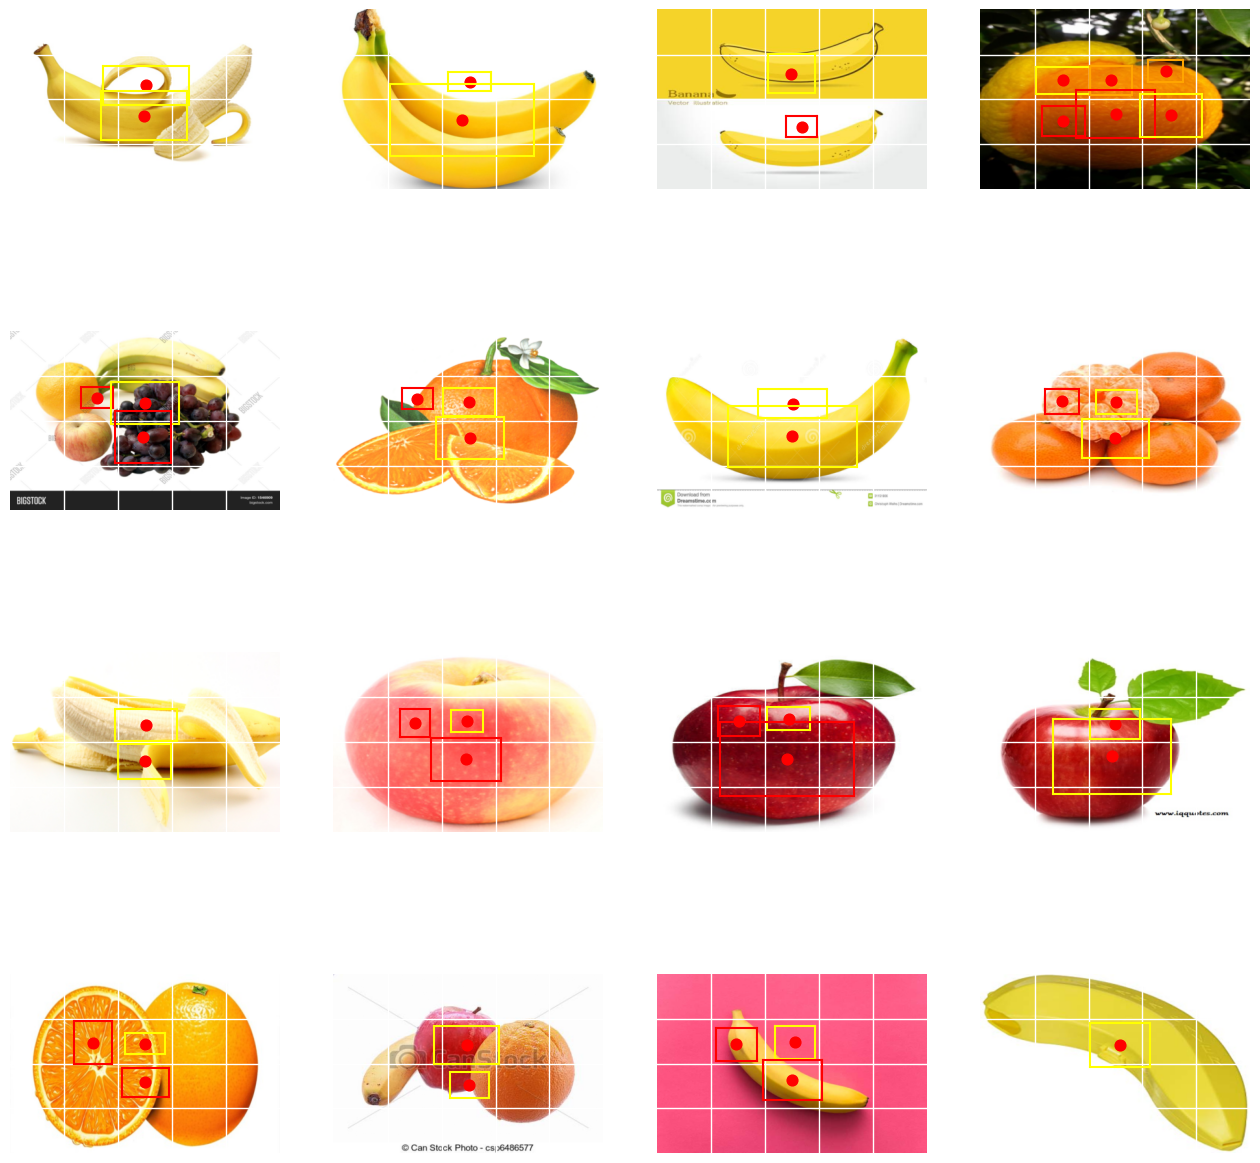

In [ ]:
# Set the model to evaluation mode
model.eval()

for image_batch, targets_batch in val_loader:
    test_images = image_batch
    with torch.inference_mode(): # disable gradient calculation
        test_images = test_images.to(device)

        # only feedforward pass
        test_targets = model(test_images)
        fig, axes = plt.subplots(4, 4, figsize=(16, 16))
        axes = axes.flatten()

        for i in range(16):
            ax = axes[i]
            img = test_images[i].cpu()  # Current image tensor
            targets = test_targets[i].cpu()  # Corresponding targets tensor

            # Assuming num_classes is known, adjust as necessary
            num_classes = len(classes)  # Example: change this to your actual number of classes

            # Call the visualization function for the current subplot axis
            visualize_with_targets(ax, img, targets, num_classes, threshold = 0.2)
            #break
        plt.show()
        break

Our model turned out to be a bit too weak for this problem. At home you can try using another, stronger model for which we provide the code below.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, grid_height=4, grid_width=5, K=2, num_kernels=8, img_width = 416, img_height = 277):
        super(SimpleCNN, self).__init__()
        self.grid_height = grid_height
        self.grid_width = grid_width
        self.K = K

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, num_kernels, kernel_size = 3, padding = 'same'),
            nn.BatchNorm2d(num_kernels),
            nn.ReLU(),
            nn.Conv2d(num_kernels, num_kernels, kernel_size = 3, padding = 'same'),
            nn.BatchNorm2d(num_kernels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
            )

        num_kernels *= 2
        self.conv2 = nn.Sequential(
          nn.Conv2d(num_kernels // 2, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.Conv2d(num_kernels, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2, stride = 2)
          )

        num_kernels *= 2
        self.conv3 = nn.Sequential(
          nn.Conv2d(num_kernels // 2, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.Conv2d(num_kernels, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2, stride = 2)
          )



        N = (K + 4 + 1) * grid_height * grid_width
        self.drop = nn.Dropout(p=0.3)

        self.fc = nn.Linear((img_width // 8) * (img_height // 8) * num_kernels, N)

    def forward(self, x):
        # Feedforward path in PyTorch
        x = self.conv1(x) # convolutional layer
        # x = self.batch(x)
        # x = self.relu(x)
        # x = self.maxpool(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), - 1) # Flatten the tensor before linear layer
        x = self.drop(x)
        x = self.fc(x) # Linear layer
        # Reshape to [batch_size, grid_height, grid_width, K+4+1]
        x = x.view(-1, self.grid_height, self.grid_width, self.K + 4 + 1)

        # Softmax if we had to use it would have been here:
        # x[..., 0:self.K] = torch.Softmax(x[..., 0:self.K]) # first K are responsible for K classes

        # Apply tanh to object center coordinates (assumed to be the next two values after class scores)
        x[..., self.K:self.K+2] = torch.tanh(x[..., self.K:self.K+2])

        # Apply sigmoid to width, height, and confidence (the next three values)
        x[..., self.K+2:self.K+5] = torch.sigmoid(x[..., self.K+2:self.K+5])
        return x

# YOLO

In [ ]:
# ultralytics is installed from pixi.toml; no in-notebook pip install is needed.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
class_names = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"
              ]

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


0: 256x416 1 banana, 1 scissors, 9.1ms
Speed: 0.8ms preprocess, 9.1ms inference, 2.8ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 1 banana, 6.2ms
Speed: 0.7ms preprocess, 6.2ms inference, 2.2ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 2 bananas, 6.3ms
Speed: 0.6ms preprocess, 6.3ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 2 oranges, 8.6ms
Speed: 0.6ms preprocess, 8.6ms inference, 2.5ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 1 banana, 1 apple, 1 orange, 6.5ms
Speed: 0.6ms preprocess, 6.5ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 3 oranges, 5.7ms
Speed: 0.6ms preprocess, 5.7ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 1 banana, 5.6ms
Speed: 0.8ms preprocess, 5.6ms inference, 1.9ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 6 oranges, 6.2ms
Speed: 0.7ms preprocess, 6.2ms inference, 1.9ms postprocess per image

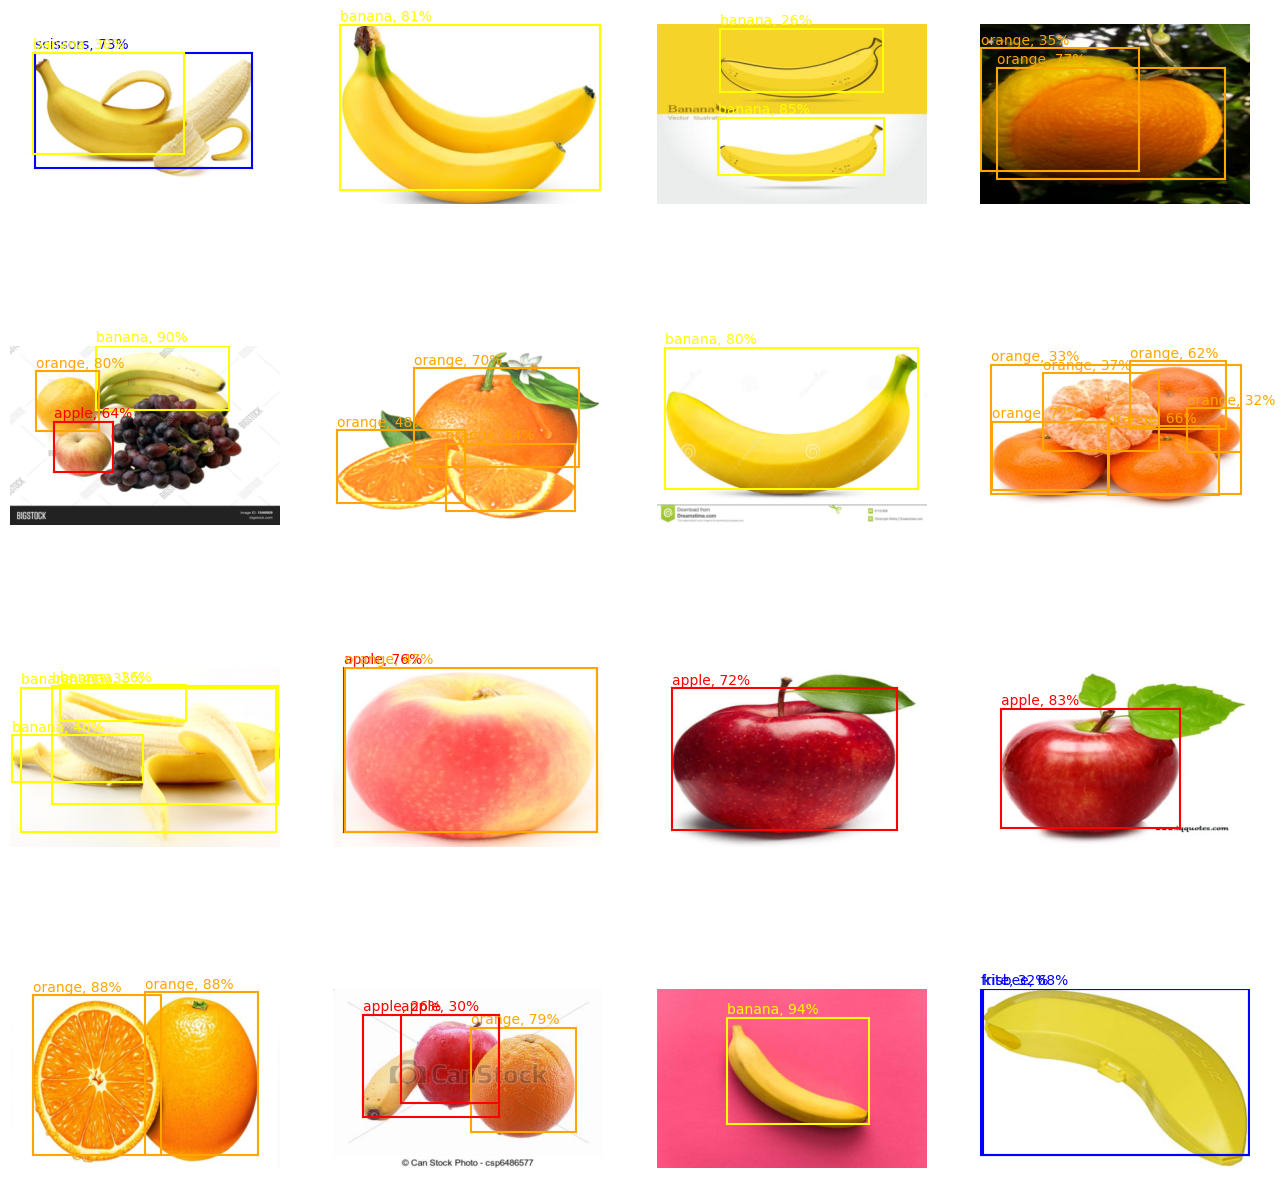

In [ ]:
for image_batch, targets_batch in val_loader:
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()

    for i in range(16):
        ax = axes[i]
        img = image_batch[i:i+1]
        results = model(img[:, :, 10:-11, :]) # YOLO requires input image size to be divisible by 32 - so we crop image width to 256
        boxes = results[0].boxes

        if isinstance(img, torch.Tensor):
          img = img[0].permute(1, 2, 0).numpy()  # Convert from [C, H, W] to [H, W, C]

        ax.imshow(img)
        ax.axis('off')  # Hide axis

        for box in boxes:

          x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

          confidence = np.round(box.conf.item(), 2)
          cls = class_names[int(box.cls[0])]

          colours = {'apple': 'red', 'banana': 'yellow', 'orange': 'orange'}
          if cls in colours:
            color = colours[cls]
          else:
            color = 'blue'

          ax.plot([x1, x1], [y1, y2], '-', color=color)  # Left edge
          ax.plot([x2, x2], [y1, y2], '-', color=color)  # Right edge
          ax.plot([x1, x2], [y1, y1], '-', color=color)  # Top edge
          ax.plot([x1, x2], [y2, y2], '-', color=color)  # Bottom edge
          ax.text(x1, y1-7, f'{cls}, {int(confidence * 100)}%', color=color, fontweight='book')

    plt.show()
    break  # Remove break to process more batches

In [ ]:
model = YOLO("yolo11n.pt")


In [ ]:
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


0: 256x416 2 bananas, 28.3ms
Speed: 0.9ms preprocess, 28.3ms inference, 2.1ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 1 banana, 8.0ms
Speed: 0.9ms preprocess, 8.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 1 banana, 7.7ms
Speed: 0.8ms preprocess, 7.7ms inference, 1.9ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 2 oranges, 8.6ms
Speed: 0.7ms preprocess, 8.6ms inference, 2.1ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 1 banana, 1 apple, 1 orange, 8.0ms
Speed: 0.7ms preprocess, 8.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 4 oranges, 8.0ms
Speed: 0.8ms preprocess, 8.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 1 banana, 8.1ms
Speed: 0.9ms preprocess, 8.1ms inference, 2.2ms postprocess per image at shape (1, 3, 256, 416)

0: 256x416 4 oranges, 8.2ms
Speed: 0.6ms preprocess, 8.2ms inference, 2.0ms postprocess per image at shape 

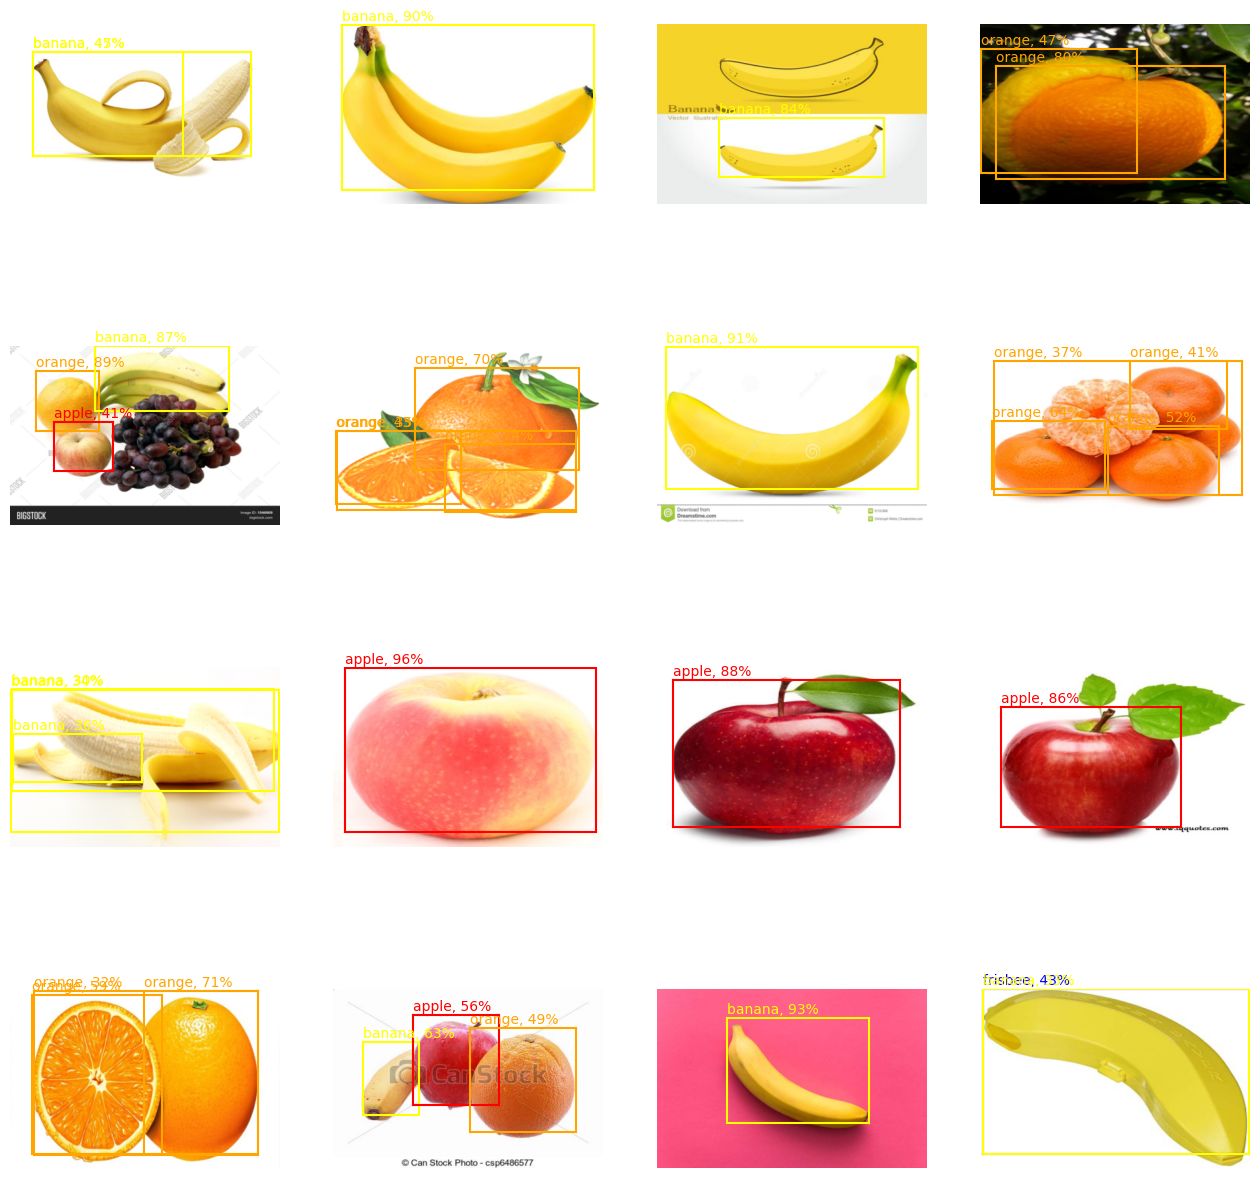

In [ ]:
for image_batch, targets_batch in val_loader:
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()

    for i in range(16):
        ax = axes[i]
        img = image_batch[i:i+1]
        results = model(img[:, :, 10:-11, :]) # YOLO requires input image size to be divisible by 32 - so we crop image width to 256
        boxes = results[0].boxes

        if isinstance(img, torch.Tensor):
          img = img[0].permute(1, 2, 0).numpy()  # Convert from [C, H, W] to [H, W, C]

        ax.imshow(img)
        ax.axis('off')  # Hide axis

        for box in boxes:

          x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

          confidence = np.round(box.conf.item(), 2)
          cls = class_names[int(box.cls[0])]

          colours = {'apple': 'red', 'banana': 'yellow', 'orange': 'orange'}
          if cls in colours:
            color = colours[cls]
          else:
            color = 'blue'

          ax.plot([x1, x1], [y1, y2], '-', color=color)  # Left edge
          ax.plot([x2, x2], [y1, y2], '-', color=color)  # Right edge
          ax.plot([x1, x2], [y1, y1], '-', color=color)  # Top edge
          ax.plot([x1, x2], [y2, y2], '-', color=color)  # Bottom edge
          ax.text(x1, y1-7, f'{cls}, {int(confidence * 100)}%', color=color, fontweight='book')

    plt.show()
    break  # Remove break to process more batches

Happy end 🔆! (hopefully)